In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
DATA_PATH = Path("../data/raw/flights_2025_01.csv")

df = pd.read_csv(DATA_PATH, low_memory=False)

completed = df[
    (df["CANCELLED"] == 0) &
    (df["DIVERTED"] == 0) &
    (df["ARR_DEL15"].notna())
].copy()

completed["ROUTE"] = completed["ORIGIN"] + "_" + completed["DEST"]

target = "ARR_DEL15"

numeric_features = [
    "MONTH",
    "DAY_OF_MONTH",
    "DAY_OF_WEEK",
    "CRS_DEP_TIME",
    "CRS_ARR_TIME",
    "DISTANCE",
    "DISTANCE_GROUP"
]

categorical_features = [
    "OP_UNIQUE_CARRIER",
    "ORIGIN",
    "DEST",
    "DEP_TIME_BLK",
    "ARR_TIME_BLK"
]

features = numeric_features + categorical_features

X = completed[features]
y = completed[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [3]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [4]:
dummy_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DummyClassifier(strategy="most_frequent"))
    ]
)

dummy_model.fit(X_train, y_train)

dummy_preds = dummy_model.predict(X_test)

In [5]:
log_reg_balanced_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ))
    ]
)

log_reg_balanced_model.fit(X_train, y_train)

log_reg_preds = log_reg_balanced_model.predict(X_test)
log_reg_probs = log_reg_balanced_model.predict_proba(X_test)[:, 1]

In [6]:
log_reg_plain_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000
        ))
    ]
)

log_reg_plain_model.fit(X_train, y_train)

plain_preds = log_reg_plain_model.predict(X_test)
plain_probs = log_reg_plain_model.predict_proba(X_test)[:, 1]

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=100,
            max_depth=20,
            min_samples_leaf=10,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, rf_preds))
print("Precision:", precision_score(y_test, rf_preds))
print("Recall:", recall_score(y_test, rf_preds))
print("F1:", f1_score(y_test, rf_preds))
print("ROC-AUC:", roc_auc_score(y_test, rf_probs))

print()
print(classification_report(y_test, rf_preds))

Random Forest Results
Accuracy: 0.6393149137419343
Precision: 0.289014097678442
Recall: 0.6298787322938959
F1: 0.39622429846632157
ROC-AUC: 0.6882477287553865

              precision    recall  f1-score   support

           0       0.88      0.64      0.74     84828
           1       0.29      0.63      0.40     19626

    accuracy                           0.64    104454
   macro avg       0.59      0.64      0.57    104454
weighted avg       0.77      0.64      0.68    104454



In [8]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import OneHotEncoder

categorical_transformer_dense = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

preprocessor_dense = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer_dense, categorical_features)
    ]
)

In [9]:
hgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_dense),
        ("model", HistGradientBoostingClassifier(
            max_iter=100,
            learning_rate=0.1,
            max_leaf_nodes=31,
            random_state=42
        ))
    ]
)

hgb_model.fit(X_train, y_train)

hgb_preds = hgb_model.predict(X_test)
hgb_probs = hgb_model.predict_proba(X_test)[:, 1]

print("HistGradientBoosting Results")
print("Accuracy:", accuracy_score(y_test, hgb_preds))
print("Precision:", precision_score(y_test, hgb_preds, zero_division=0))
print("Recall:", recall_score(y_test, hgb_preds, zero_division=0))
print("F1:", f1_score(y_test, hgb_preds, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, hgb_probs))

print()
print(classification_report(y_test, hgb_preds, zero_division=0))

HistGradientBoosting Results
Accuracy: 0.826603098014437
Precision: 0.7705503931379557
Recall: 0.10985427494140426
F1: 0.19229397074562968
ROC-AUC: 0.7437032269075124

              precision    recall  f1-score   support

           0       0.83      0.99      0.90     84828
           1       0.77      0.11      0.19     19626

    accuracy                           0.83    104454
   macro avg       0.80      0.55      0.55    104454
weighted avg       0.82      0.83      0.77    104454



In [10]:
comparison_results = pd.DataFrame([
    {
        "model": "Dummy Most Frequent",
        "accuracy": accuracy_score(y_test, dummy_preds),
        "precision": precision_score(y_test, dummy_preds, zero_division=0),
        "recall": recall_score(y_test, dummy_preds, zero_division=0),
        "f1": f1_score(y_test, dummy_preds, zero_division=0),
        "roc_auc": np.nan
    },
    {
        "model": "Logistic Regression Balanced",
        "accuracy": accuracy_score(y_test, log_reg_preds),
        "precision": precision_score(y_test, log_reg_preds),
        "recall": recall_score(y_test, log_reg_preds),
        "f1": f1_score(y_test, log_reg_preds),
        "roc_auc": roc_auc_score(y_test, log_reg_probs)
    },
    {
        "model": "Logistic Regression Plain",
        "accuracy": accuracy_score(y_test, plain_preds),
        "precision": precision_score(y_test, plain_preds, zero_division=0),
        "recall": recall_score(y_test, plain_preds, zero_division=0),
        "f1": f1_score(y_test, plain_preds, zero_division=0),
        "roc_auc": roc_auc_score(y_test, plain_probs)
    },
    {
        "model": "Random Forest Balanced",
        "accuracy": accuracy_score(y_test, rf_preds),
        "precision": precision_score(y_test, rf_preds),
        "recall": recall_score(y_test, rf_preds),
        "f1": f1_score(y_test, rf_preds),
        "roc_auc": roc_auc_score(y_test, rf_probs)
    },
    {
        "model": "HistGradientBoosting",
        "accuracy": accuracy_score(y_test, hgb_preds),
        "precision": precision_score(y_test, hgb_preds, zero_division=0),
        "recall": recall_score(y_test, hgb_preds, zero_division=0),
        "f1": f1_score(y_test, hgb_preds, zero_division=0),
        "roc_auc": roc_auc_score(y_test, hgb_probs)
    }
])

comparison_results.sort_values("f1", ascending=False)

,model,accuracy,precision,recall,f1,roc_auc
3,Random Forest Balanced,0.639315,0.289014,0.629879,0.396224,0.688248
1,Logistic Regression Balanced,0.602370,0.261662,0.612759,0.366725,0.647779
4,HistGradientBoosting,0.826603,0.770550,0.109854,0.192294,0.743703
2,Logistic Regression Plain,0.811984,0.448000,0.002853,0.005671,0.648302
0,Dummy Most Frequent,0.812109,0.000000,0.000000,0.000000,NaN


In [11]:
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

hgb_threshold_results = []

for threshold in thresholds:
    hgb_threshold_preds = (hgb_probs >= threshold).astype(int)

    hgb_threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, hgb_threshold_preds),
        "precision": precision_score(y_test, hgb_threshold_preds, zero_division=0),
        "recall": recall_score(y_test, hgb_threshold_preds, zero_division=0),
        "f1": f1_score(y_test, hgb_threshold_preds, zero_division=0)
    })

hgb_threshold_results_df = pd.DataFrame(hgb_threshold_results)
hgb_threshold_results_df.sort_values("f1", ascending=False)

,threshold,accuracy,precision,recall,f1
3,0.25,0.774054,0.416628,0.506063,0.457011
2,0.20,0.711998,0.351154,0.628503,0.450569
4,0.30,0.805551,0.478914,0.396362,0.433745
1,0.15,0.585636,0.282053,0.779935,0.414285
5,0.35,0.821577,0.545363,0.302915,0.389491
0,0.10,0.381412,0.224007,0.930246,0.361067
6,0.40,0.829111,0.625779,0.225110,0.331110
7,0.45,0.829035,0.696009,0.159941,0.260109
8,0.50,0.826603,0.770550,0.109854,0.192294


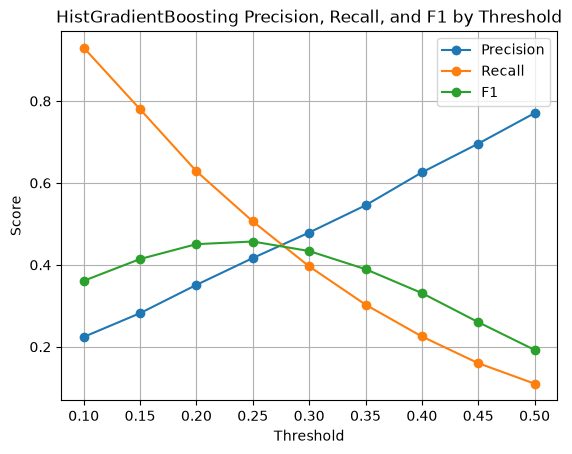

In [12]:
plt.plot(hgb_threshold_results_df["threshold"], hgb_threshold_results_df["precision"], marker="o", label="Precision")
plt.plot(hgb_threshold_results_df["threshold"], hgb_threshold_results_df["recall"], marker="o", label="Recall")
plt.plot(hgb_threshold_results_df["threshold"], hgb_threshold_results_df["f1"], marker="o", label="F1")

plt.title("HistGradientBoosting Precision, Recall, and F1 by Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
thresholds = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

rf_threshold_results = []

for threshold in thresholds:
    rf_threshold_preds = (rf_probs >= threshold).astype(int)

    rf_threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, rf_threshold_preds),
        "precision": precision_score(y_test, rf_threshold_preds, zero_division=0),
        "recall": recall_score(y_test, rf_threshold_preds, zero_division=0),
        "f1": f1_score(y_test, rf_threshold_preds, zero_division=0)
    })

rf_threshold_results_df = pd.DataFrame(rf_threshold_results)
rf_threshold_results_df.sort_values("f1", ascending=False)

,threshold,accuracy,precision,recall,f1
5,0.50,0.639315,0.289014,0.629879,0.396224
6,0.55,0.755021,0.359688,0.389432,0.373969
4,0.45,0.470762,0.238933,0.831346,0.371185
3,0.40,0.307667,0.207470,0.952053,0.340697
2,0.35,0.227440,0.194281,0.988739,0.324751
1,0.30,0.197120,0.189443,0.998319,0.318456
0,0.25,0.188112,0.187927,0.999949,0.316392
7,0.60,0.804143,0.450060,0.191022,0.268207


After threshold tuning, HistGradientBoosting became the strongest model overall. At the default 0.50 threshold, it had high precision but very low recall. Lowering the threshold to 0.25 improved recall substantially while keeping precision higher than the other models.

The best model so far is HistGradientBoosting with a 0.25 classification threshold. It achieved the highest F1-score, with about 41.7% precision and 50.6% recall for delayed flights.

In [14]:
best_threshold = 0.25

best_preds = (hgb_probs >= best_threshold).astype(int)

print("Best Model: HistGradientBoosting")
print("Threshold:", best_threshold)
print("Accuracy:", accuracy_score(y_test, best_preds))
print("Precision:", precision_score(y_test, best_preds))
print("Recall:", recall_score(y_test, best_preds))
print("F1:", f1_score(y_test, best_preds))
print("ROC-AUC:", roc_auc_score(y_test, hgb_probs))

print()
print(classification_report(y_test, best_preds))

Best Model: HistGradientBoosting
Threshold: 0.25
Accuracy: 0.7740536504107071
Precision: 0.4166282142707328
Recall: 0.5060633853052073
F1: 0.45701138847348444
ROC-AUC: 0.7437032269075124

              precision    recall  f1-score   support

           0       0.88      0.84      0.86     84828
           1       0.42      0.51      0.46     19626

    accuracy                           0.77    104454
   macro avg       0.65      0.67      0.66    104454
weighted avg       0.79      0.77      0.78    104454



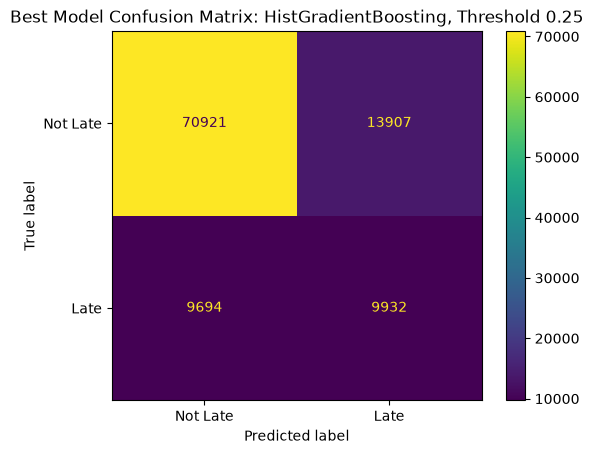

In [15]:
cm = confusion_matrix(y_test, best_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Late", "Late"]
)

disp.plot()
plt.title("Best Model Confusion Matrix: HistGradientBoosting, Threshold 0.25")
plt.show()

In [16]:
Path("../visuals").mkdir(exist_ok=True)

comparison_results.to_csv("../visuals/model_comparison_results.csv", index=False)
hgb_threshold_results_df.to_csv("../visuals/hgb_threshold_results.csv", index=False)
rf_threshold_results_df.to_csv("../visuals/rf_threshold_results.csv", index=False)